
# CREDIT CARD FRAUD DETECTION


## 1)LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier, plot_importance

import warnings
warnings.filterwarnings("ignore")

## 2) LOAD DATASET

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3) DATASET CHECK

In [3]:
print("Shape of dataset:", df.shape)
print("\nDataset info:")
print(df.info())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nClass counts:")
print(df['Class'].value_counts())

print("\nClass percentages:")
print(df['Class'].value_counts(normalize=True) * 100)

Shape of dataset: (284807, 31)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V2

## 4) CLASS DISTRIBUTION

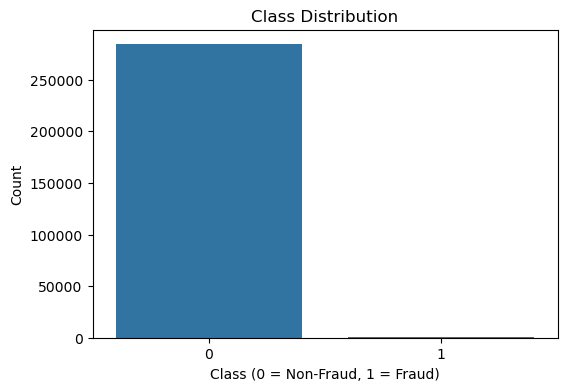

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

## 5) DISTRIBUTION OF TIME AND AMOUNT

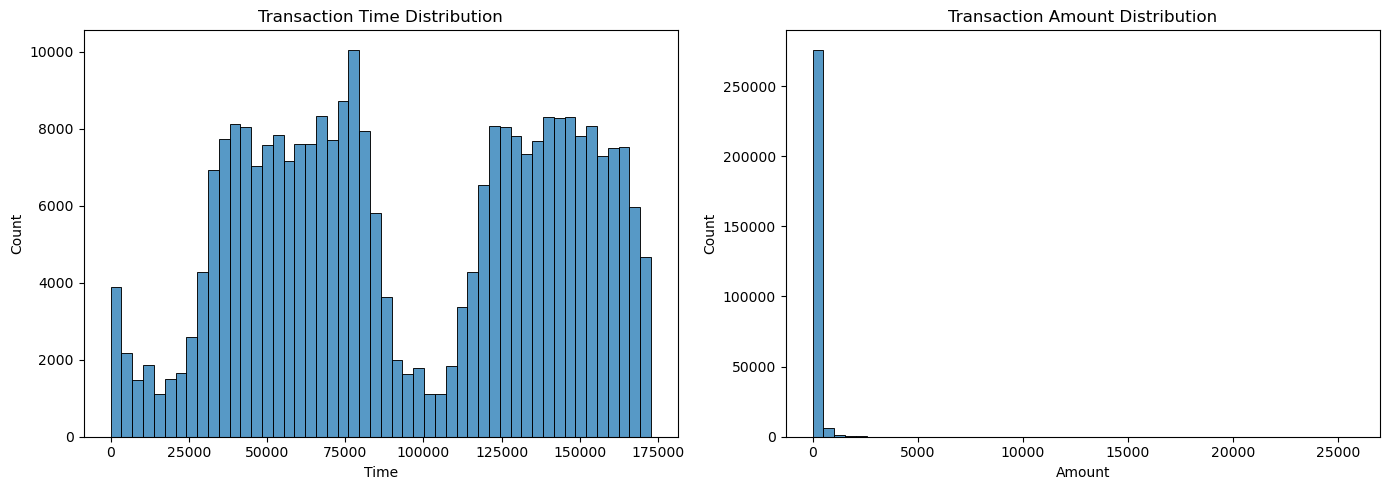

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Time'], bins=50, ax=ax[0], kde=False)
ax[0].set_title("Transaction Time Distribution")

sns.histplot(df['Amount'], bins=50, ax=ax[1], kde=False)
ax[1].set_title("Transaction Amount Distribution")

plt.tight_layout()
plt.show()

## 6) CORRELATION HEATMAP

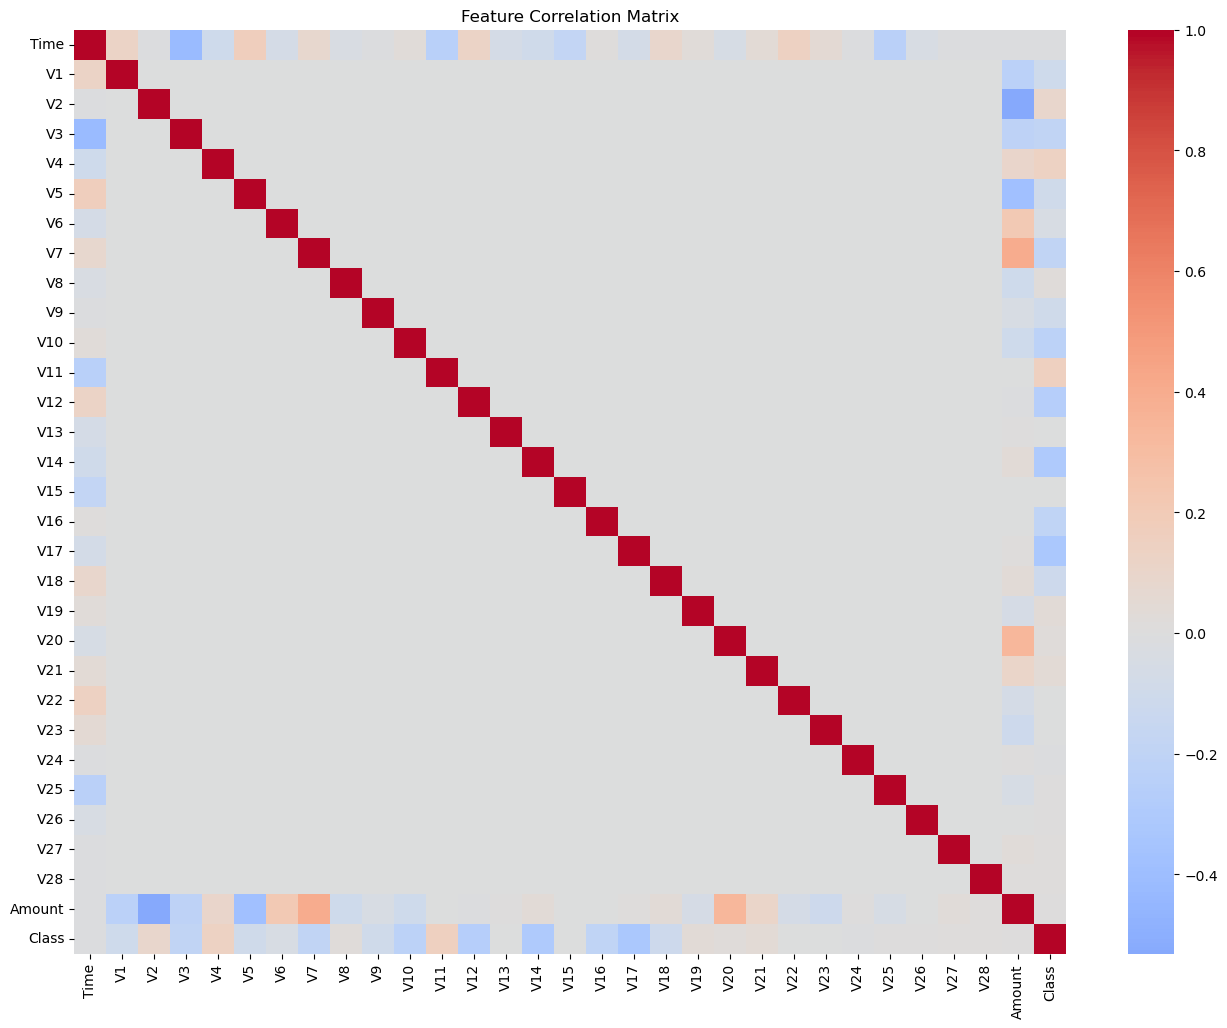

In [6]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## 7) FEATURE / TARGET SPLIT

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

## 8) TRAIN-TEST SPLIT

In [8]:
# Train / Validation / Test split
# Train: model training
# Validation: threshold optimization
# Test: final unbiased evaluation

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:\n", y_train.value_counts(normalize=True))
print("\ny_val distribution:\n", y_val.value_counts(normalize=True))
print("\ny_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (199364, 30)
X_val shape: (42721, 30)
X_test shape: (42722, 30)

y_train distribution:
 Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

y_val distribution:
 Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64

y_test distribution:
 Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


## 9) BASELINE MODEL - LOGISTIC REGRESSION

In [9]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print("PR-AUC:", average_precision_score(y_test, y_prob_base))
print(classification_report(y_test, y_pred_base))
print(confusion_matrix(y_test, y_pred_base))

=== Logistic Regression ===
ROC-AUC: 0.9679722632029891
PR-AUC: 0.7928733741399766
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42648
           1       0.07      0.88      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.56     42722
weighted avg       1.00      0.98      0.99     42722

[[41745   903]
 [    9    65]]


## 10) SMOTE + LOGISTIC REGRESSION

In [10]:
smote_lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

smote_lr_pipeline.fit(X_train, y_train)

y_pred_smote_lr = smote_lr_pipeline.predict(X_test)
y_prob_smote_lr = smote_lr_pipeline.predict_proba(X_test)[:, 1]

print("=== SMOTE + Logistic Regression ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_smote_lr))
print(classification_report(y_test, y_pred_smote_lr))
print(confusion_matrix(y_test, y_pred_smote_lr))

=== SMOTE + Logistic Regression ===
ROC-AUC: 0.9675223197310985
PR-AUC: 0.7935397719557851
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42648
           1       0.06      0.88      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.55     42722
weighted avg       1.00      0.98      0.99     42722

[[41692   956]
 [    9    65]]


## 11) RANDOM FOREST

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
ROC-AUC: 0.9702790156504282
PR-AUC: 0.8028705362699722
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.92      0.77      0.84        74

    accuracy                           1.00     42722
   macro avg       0.96      0.89      0.92     42722
weighted avg       1.00      1.00      1.00     42722

[[42643     5]
 [   17    57]]


## 12) XGBOOST

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
ROC-AUC: 0.9706592495703357
PR-AUC: 0.8400117499232937
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.88      0.81      0.85        74

    accuracy                           1.00     42722
   macro avg       0.94      0.91      0.92     42722
weighted avg       1.00      1.00      1.00     42722

[[42640     8]
 [   14    60]]


## 13) THRESHOLD OPTIMIZATION FOR XGBOOST

In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])   # thresholds length is one less than precision/recall
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 from threshold search:", f1_scores[best_idx])

y_pred_xgb_opt = (y_prob_xgb >= best_threshold).astype(int)

print("=== Optimized Threshold XGBoost ===")
print(classification_report(y_test, y_pred_xgb_opt))
print(confusion_matrix(y_test, y_pred_xgb_opt))
print("Precision:", precision_score(y_test, y_pred_xgb_opt))
print("Recall:", recall_score(y_test, y_pred_xgb_opt))
print("F1:", f1_score(y_test, y_pred_xgb_opt))

Best threshold: 0.9603703
Best F1 from threshold search: 0.8529411764209774
=== Optimized Threshold XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.94      0.78      0.85        74

    accuracy                           1.00     42722
   macro avg       0.97      0.89      0.93     42722
weighted avg       1.00      1.00      1.00     42722

[[42644     4]
 [   16    58]]
Precision: 0.9354838709677419
Recall: 0.7837837837837838
F1: 0.8529411764705882


## 14) HYPERPARAMETER TUNING - XGBOOST

In [14]:
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

xgb_tune = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("Best parameters:")
print(search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}


## 15) TUNED XGBOOST EVALUATION

In [15]:
# Probability predictions for final tuned XGBoost on test set

y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Test ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print("Tuned XGBoost Test PR-AUC:", average_precision_score(y_test, y_prob_best))

Tuned XGBoost Test ROC-AUC: 0.977290212271923
Tuned XGBoost Test PR-AUC: 0.8434133996594616


## 16) THRESHOLD OPTIMIZATION FOR TUNED XGBOOST

In [16]:
# Threshold optimization on VALIDATION set

y_prob_val_best = best_xgb.predict_proba(X_val)[:, 1]

prec_val, rec_val, thr_val = precision_recall_curve(y_val, y_prob_val_best)

f1_scores_val = 2 * (prec_val * rec_val) / (prec_val + rec_val + 1e-10)
best_idx_val = np.argmax(f1_scores_val[:-1])
best_threshold_best = thr_val[best_idx_val]

print("Best threshold selected on validation set:", best_threshold_best)
print("Best validation F1:", f1_scores_val[best_idx_val])

# Final evaluation on TEST set
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best_opt = (y_prob_best >= best_threshold_best).astype(int)

print("=== Final Tuned XGBoost Evaluation on Test Set ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print("PR-AUC:", average_precision_score(y_test, y_prob_best))
print(classification_report(y_test, y_pred_best_opt))
print(confusion_matrix(y_test, y_pred_best_opt))

print("Precision:", precision_score(y_test, y_pred_best_opt))
print("Recall:", recall_score(y_test, y_pred_best_opt))
print("F1:", f1_score(y_test, y_pred_best_opt))

Best threshold selected on validation set: 0.74412245
Best validation F1: 0.8529411764209774
=== Final Tuned XGBoost Evaluation on Test Set ===
ROC-AUC: 0.977290212271923
PR-AUC: 0.8434133996594616
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.90      0.81      0.85        74

    accuracy                           1.00     42722
   macro avg       0.95      0.91      0.93     42722
weighted avg       1.00      1.00      1.00     42722

[[42641     7]
 [   14    60]]
Precision: 0.8955223880597015
Recall: 0.8108108108108109
F1: 0.851063829787234


## 17) RESULTS TABLE

In [17]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SMOTE + Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_smote_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_best)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_base),
        average_precision_score(y_test, y_prob_smote_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_smote_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_smote_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best_opt)
    ],
    "F1": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_smote_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best_opt)
    ]
})

results = results.sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Tuned XGBoost,0.977290,0.843413,0.895522,0.810811,0.851064
1,XGBoost,0.970659,0.840012,0.882353,0.810811,0.845070
2,Random Forest,0.970279,0.802871,0.919355,0.770270,0.838235
3,SMOTE + Logistic Regression,0.967522,0.793540,0.063663,0.878378,0.118721
4,Logistic Regression,0.967972,0.792873,0.067149,0.878378,0.124760


## 18) ROC CURVE COMPARISON

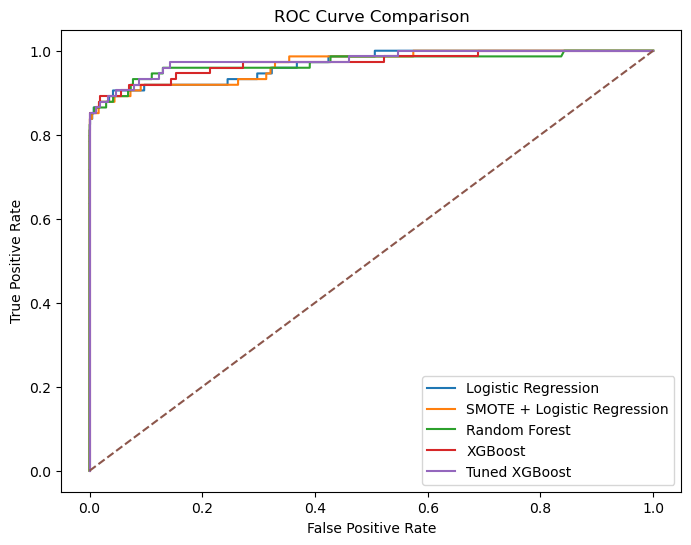

In [18]:
plt.figure(figsize=(8,6))

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
plt.plot(fpr_base, tpr_base, label="Logistic Regression")

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote_lr)
plt.plot(fpr_smote, tpr_smote, label="SMOTE + Logistic Regression")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
plt.plot(fpr_best, tpr_best, label="Tuned XGBoost")

plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 19) PRECISION-RECALL CURVE COMPARISON

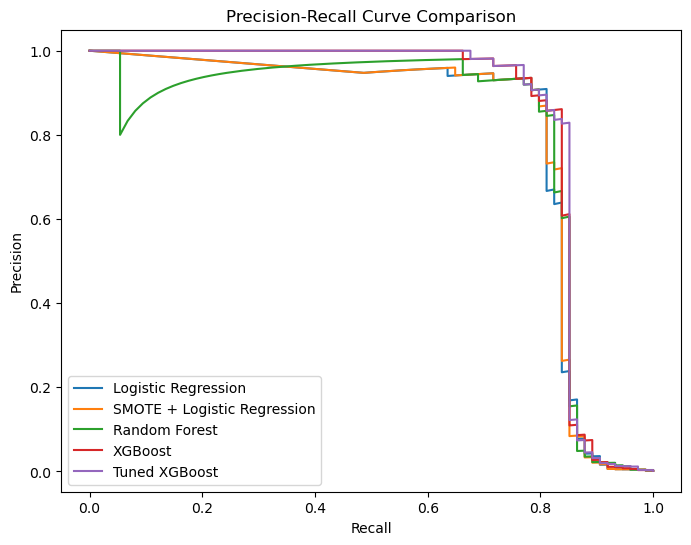

In [19]:
plt.figure(figsize=(8,6))

for y_prob, label in [
    (y_prob_base, "Logistic Regression"),
    (y_prob_smote_lr, "SMOTE + Logistic Regression"),
    (y_prob_rf, "Random Forest"),
    (y_prob_xgb, "XGBoost"),
    (y_prob_best, "Tuned XGBoost")
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(rec, prec, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

## 20) FINAL CONFUSION MATRIX

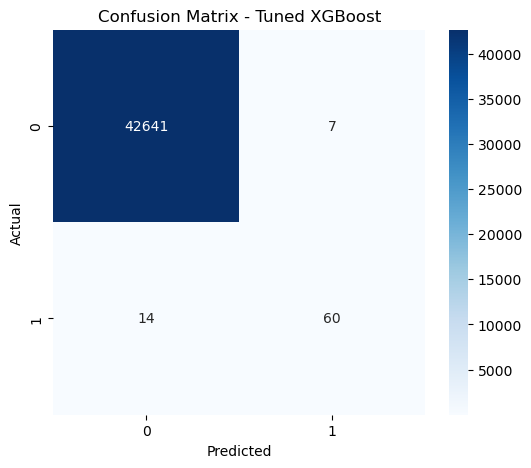

In [20]:
cm = confusion_matrix(y_test, y_pred_best_opt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 21) FINAL MODEL ROC CURVE

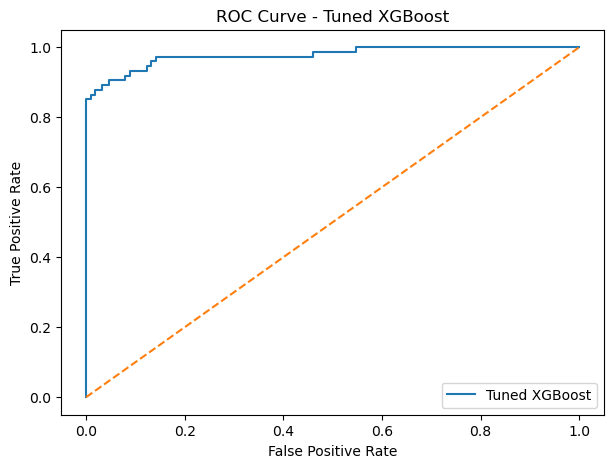

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Tuned XGBoost")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.show()

## 22) FINAL MODEL PRECISION-RECALL CURVE

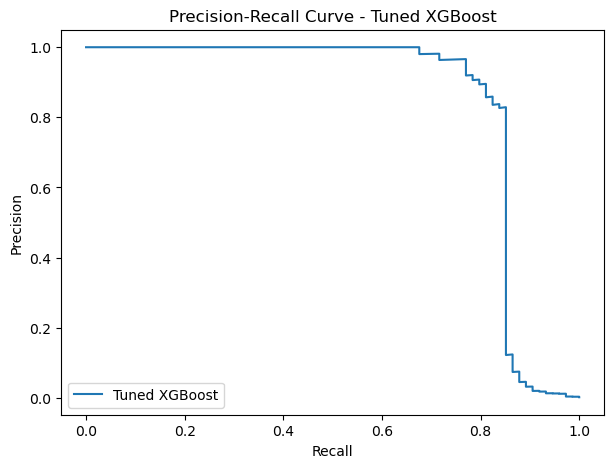

In [22]:
prec, rec, _ = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label="Tuned XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned XGBoost")
plt.legend()
plt.show()

## 23) FEATURE IMPORTANCE

<Figure size 1000x800 with 0 Axes>

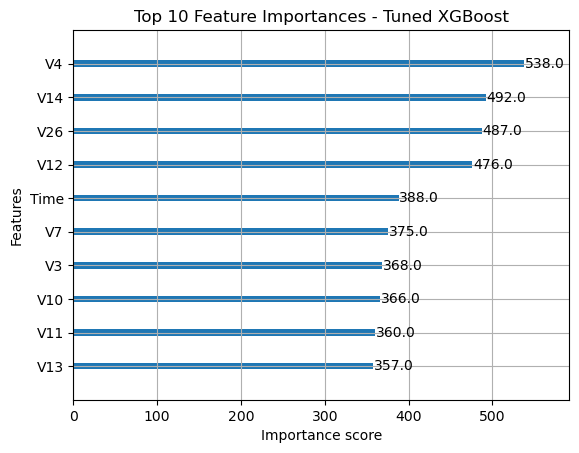

In [23]:
plt.figure(figsize=(10,8))
plot_importance(best_xgb, max_num_features=10)
plt.title("Top 10 Feature Importances - Tuned XGBoost")
plt.show()

## 24) Comparable metrics readable from Kaggle notebook.

In [24]:
# Kaggle baseline values manually read from the selected Kaggle notebook
# ROC-AUC was not clearly provided/readable, so it is kept as N/A.
kaggle_roc_auc = np.nan
kaggle_pr_auc = 0.75
kaggle_precision = 0.10
kaggle_recall = 0.86
kaggle_f1 = 0.19

# Our final model: Tuned XGBoost with optimized threshold
our_roc_auc = roc_auc_score(y_test, y_prob_best)
our_pr_auc = average_precision_score(y_test, y_prob_best)
our_precision = precision_score(y_test, y_pred_best_opt)
our_recall = recall_score(y_test, y_pred_best_opt)
our_f1 = f1_score(y_test, y_pred_best_opt)

kaggle_vs_ours = pd.DataFrame({
    "Model / Source": [
        "Selected Kaggle Baseline",
        "Our Final Tuned XGBoost"
    ],
    "Dataset": [
        "European Credit Card Fraud Dataset",
        "European Credit Card Fraud Dataset"
    ],
    "Imbalance Handling": [
        "Reported in Kaggle notebook",
        "scale_pos_weight + threshold optimization"
    ],
    "ROC-AUC": [
        kaggle_roc_auc,
        our_roc_auc
    ],
    "PR-AUC": [
        kaggle_pr_auc,
        our_pr_auc
    ],
    "Precision": [
        kaggle_precision,
        our_precision
    ],
    "Recall": [
        kaggle_recall,
        our_recall
    ],
    "F1-score": [
        kaggle_f1,
        our_f1
    ]
})

kaggle_vs_ours.style.format({
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
}, na_rep="N/A")

,Model / Source,Dataset,Imbalance Handling,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Selected Kaggle Baseline,European Credit Card Fraud Dataset,Reported in Kaggle notebook,N/A,0.7500,0.1000,0.8600,0.1900
1,Our Final Tuned XGBoost,European Credit Card Fraud Dataset,scale_pos_weight + threshold optimization,0.9773,0.8434,0.8955,0.8108,0.8511


## 25) Final improvement summary based on Our Final Tuned XGBoost

In [25]:
kaggle_pr_auc = 0.75
kaggle_precision = 0.10
kaggle_recall = 0.86
kaggle_f1 = 0.19

# Our final model: Tuned XGBoost with optimized threshold
our_pr_auc = average_precision_score(y_test, y_prob_best)
our_precision = precision_score(y_test, y_pred_best_opt)
our_recall = recall_score(y_test, y_pred_best_opt)
our_f1 = f1_score(y_test, y_pred_best_opt)

print("PR-AUC improvement:", round(our_pr_auc - kaggle_pr_auc, 4))
print("Precision improvement:", round(our_precision - kaggle_precision, 4))
print("Recall difference:", round(our_recall - kaggle_recall, 4))
print("F1 improvement:", round(our_f1 - kaggle_f1, 4))

PR-AUC improvement: 0.0934
Precision improvement: 0.7955
Recall difference: -0.0492
F1 improvement: 0.6611
